# LLoom Modular

In [ ]:
!pip install text_lloom ollama sentence-transformers -q
!pip install "transformers<5.0.0" -q

In [1]:
import pickle
from pathlib import Path
import json
import pandas as pd
import text_lloom.concept_induction as ci
import text_lloom.workbench as wb
from text_lloom.llm import Model, EmbedModel
from text_lloom.concept import Concept
 
CHECKPOINT_DIR = Path("lloom_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
 
 
def save_checkpoint(obj, name):
    with open(CHECKPOINT_DIR / f"{name}.pkl", "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved checkpoint: {name}")
 
 
def load_checkpoint(name):
    with open(CHECKPOINT_DIR / f"{name}.pkl", "rb") as f:
        return pickle.load(f)

[nltk_data] Error loading punkt_tab: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


In [ ]:
# load data (CSV file with minimum doc_id, text)
df = pd.read_csv("../data/lloom_pilot_sample.csv")

# Preview 
display(df[["doc_id", "text"]].head())

,doc_id,text
0,file7614,"s[enior]. Ornatissimo viro d. , ecclesiae mini..."
1,file11640,"134. Die gnade Ihelu Christi, unnd meine guͦtt..."
2,file10366,"Christlicher, durchlüchtiger, hochgeborner für..."
3,file9125,Quam tristis fuerit mihi a vobis discessus ob ...
4,file2223,"Quod rarius ad te scribo, id facio, quod occup..."


In [3]:
# Create LLoom instance

from text_lloom.llm import Model, EmbedModel

def setup_llm_fn(api_key):
    from openai import OpenAI
    return OpenAI(api_key="local", base_url="http://127.0.0.1:8080/v1") # local server for Ollama / Turbofieldflare

def setup_embed_fn(api_key):
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("all-MiniLM-L6-v2")

async def call_llm_fn(model, prompt):
    if "system_prompt" not in model.args:
        model.args["system_prompt"] = (
            "You are a helpful assistant who helps with identifying patterns in text examples from 16th century letters written during the Reformation. Pay attention to theological ideas and arguments."
            "Always respond with raw JSON only."
            "When generating concepts, each concept MUST include ALL required fields: "
            "name, prompt, and example_ids (a list of document IDs, use an empty list if unsure)."
        )
    res = model.client.chat.completions.create(
        model=model.name,
        temperature=0,
        max_tokens=16384,
        messages=[
            {"role": "system", "content": model.args["system_prompt"]},
            {"role": "user", "content": prompt},
        ]
    )
    text = res.choices[0].message.content
    # Strip markdown fences if the model adds them anyway
    text = text.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]
        text = text.strip()

    try:
        parsed = json.loads(text)

        def patch(obj):
            if isinstance(obj, dict):
                if "name" in obj and "prompt" in obj and "example_ids" not in obj:
                    obj["example_ids"] = []
                for v in obj.values():
                    patch(v)
            elif isinstance(obj, list):
                for item in obj:
                    patch(item)

        patch(parsed)
        text = json.dumps(parsed)
    except (json.JSONDecodeError, TypeError):
        pass  # unverändert zurückgeben, LLooMs eigenes Error-Handling greift dann

    return text, [0, 0]

def call_embed_fn(model, text_arr):
    embeddings = model.client.encode(text_arr)
    return embeddings.tolist(), [0, 0]

api_key = "EMPTY"

In [5]:
MODEL_NAME = "gemma-4-26b-a4b-it"

l = wb.lloom(
    df=df,
    id_col="doc_id",
    text_col="text",
    distill_model=Model(setup_fn=setup_llm_fn, fn=call_llm_fn, name=MODEL_NAME, cost=[0,0], rate_limit=(2,1), context_window=16384, api_key=api_key),
    cluster_model=EmbedModel(setup_fn=setup_embed_fn, fn=call_embed_fn, name="", cost=0, batch_size=512, api_key=api_key),
    synth_model=Model(setup_fn=setup_llm_fn, fn=call_llm_fn, name=MODEL_NAME, cost=[0,0], rate_limit=(2,1), context_window=16384, api_key=api_key),
    score_model=Model(setup_fn=setup_llm_fn, fn=call_llm_fn, name=MODEL_NAME, cost=[0,0], rate_limit=(2,1), context_window=16384, api_key=api_key),
)
cur_seed = "theologically ideas and positions of the Reformation and their justification"

In [6]:
# Step 1: Distill aka summarisation of letter text into few sentences / bullet points

bullet_df = await ci.distill_summarize(
    text_df=df, doc_col="text", doc_id_col="doc_id",
    model=l.distill_model, seed=cur_seed, sess=l,
)
print(bullet_df.shape)
print(bullet_df["text"].sample(20).tolist())

(177, 2)
['Divine judgment governs earthly political shifts', 'Religious progress remains slow and difficult', 'Conflict between personal interest and gospel', 'Distinguishing between religious piety and political zeal', 'Dynastic claims fuel regional conflict', 'Protecting the church from atheistic innovations', 'Faithful service amidst worldly tribulations', 'Protecting the church from external threats', 'Theological writings strengthening the church', 'Concerns regarding inexperienced young leaders', 'Resistance against tyranny through divine strength', 'Maintaining peace between different religious practices', 'Persecution by inquisitors for faith', "Piety requires obedience to God's will", 'Protecting piety against worldly idols', 'Divine providence amidst violent political upheaval', 'Spiritual fatherhood within the church structure', 'Securing religious governance through parliament', "Perseverance in God's word is essential", 'Promoting godly law over papacy']


In [7]:
save_checkpoint(bullet_df, MODEL_NAME + "_01_bullet_df")

Saved checkpoint: gemma-4-26b-a4b-it_01_bullet_df


In [8]:
# Step 2: Clustering aka grouping together related objects based on patterns (bullet points into embeddings, clustering with HDBScan) in their summaries from Distill

cluster_df = await ci.cluster(
    text_df=bullet_df, doc_col="text", doc_id_col="doc_id",
    embed_model=l.cluster_model, min_cluster_size=8, sess=l,
)
print(cluster_df["cluster_id"].value_counts())
save_checkpoint(cluster_df, MODEL_NAME + "_02_cluster_df")

cluster_id
-1    96
 1    15
 6    12
 0    11
 4    10
 7     9
 2     8
 3     8
 5     8
Name: count, dtype: int64
Saved checkpoint: gemma-4-26b-a4b-it_02_cluster_df


In [10]:
cluster_df["doc_id"].nunique()

47

In [9]:
# Step 3: Synthesize aka identify unifying concepts with LLM prompting 

concept_df, logs = await ci.synthesize(
    cluster_df=cluster_df, doc_col="text", doc_id_col="doc_id",
    model=l.synth_model, seed=cur_seed, batch_size=15,
    sess=l, return_logs=True,
)
for c_id, c in l.concepts.items():
    print(c.name, "—", c.prompt)

save_checkpoint(concept_df, MODEL_NAME + "_03_concept_df")
save_checkpoint(l.concepts, MODEL_NAME + "_03_concepts_dict")   

Rejection of Papal Authority — Does the text argue against the authority of the Pope or the Roman papacy in favor of national or godly law?
Justification by Faith — Does the text discuss the rejection of human works in favor of Christ's righteousness for justification?
Anti-Lutheran Polemics — Does the text express opposition to Lutheran doctrines or practices to preserve religious purity?
Civic and Noble Loyalty — Does the text emphasize obedience to secular authority, duty, or loyalty to noble figures?
National Ecclesiastical Law — Does the text advocate for the establishment of independent national religious laws?
Defense of Orthodoxy — Does the text focus on combatting heresy, theological pride, or clarifying Christological doctrines?
Virtue in Service — Does the text link religious duty to the maintenance of virtue in worldly affairs or service?
Scriptural Authority — Does the text emphasize the supreme authority and truth of the Holy Scriptures?
Divine Authority Obedience — Does 

In [ ]:
concepts_out, concept_df_out, review_logs = await ci.review(
    concepts=l.concepts, concept_df=concept_df, concept_col_prefix="concept",
    model=l.synth_model, seed=cur_seed, sess=l, return_logs=True,
)
print(review_logs)
save_checkpoint(concepts_out, MODEL_NAME + "_04_concepts_out")
save_checkpoint(concept_df_out, MODEL_NAME + "_04_concept_df_out")


    Auto-review:
    Removed (2):
        ['Worldly Influence', 'Hypocritical Profession']
    Merged (8): 
    	['Rejection of Papal Authority', 'Anti-Papal Resistance'] --> Anti-Papal Authority: Does the text argue against the authority of the Pope or the Roman papacy in favor of national or godly law?
	['Scriptural Authority', 'Sola Scriptura Authority'] --> Scriptural Supremacy: Does the text assert that the Holy Scriptures are the ultimate and supreme authority for all theological truth and practice?
	['Doctrinal Defense', 'Confessional Defense'] --> Doctrinal Defense: Does the text focus on defending specific theological doctrines or creeds against opposing factions or external opposition?
	['Resistance to Authority', 'Resistance to Tyranny'] --> Resistance to Tyranny: Does the text argue for resisting worldly or political tyranny through the strength of faith and conscience?
	['Ecclesiastical Order', 'Divine Order Stability'] --> Ecclesiastical Order: Does the text focus on mai

In [14]:
# Inspect current concepts
for cid, c in l.concepts.items():
    print(cid, "|", c.name, "|", c.prompt)

d07b8c7d-72be-43f1-b6af-5e3fe7ba50fe | Justification by Faith | Does the text discuss the rejection of human works in favor of Christ's righteousness for justification?
4b017284-ac42-44b1-a062-9dfe868b5684 | Anti-Lutheran Polemics | Does the text express opposition to Lutheran doctrines or practices to preserve religious purity?
d999e046-7db8-42e3-a0b7-317eccdb862d | Civic and Noble Loyalty | Does the text emphasize obedience to secular authority, duty, or loyalty to noble figures?
70d40fcf-e8ab-44f6-ab38-8b6cab9f4b25 | National Ecclesiastical Law | Does the text advocate for the establishment of independent national religious laws?
25a2a45d-389d-417e-9d54-aab1f5a6b6e5 | Defense of Orthodoxy | Does the text focus on combatting heresy, theological pride, or clarifying Christological doctrines?
5373271c-0454-4b4c-a6e4-15e4a7fbb83b | Virtue in Service | Does the text link religious duty to the maintenance of virtue in worldly affairs or service?
b59df34a-ce90-44b2-85c0-2885ab768118 | Divi

In [15]:
selected_ids = [
    "d07b8c7d-72be-43f1-b6af-5e3fe7ba50fe",  # Justification by Faith
    "8b113d25-8fa6-4ee1-be2b-a2c1e57c3054",  # Scriptural Supremacy
    "ad9d2035-4f00-47ba-9b42-fdef9017c461",  # Anti-Papal Authority
    "ebcf10ec-1358-4d59-abc8-43faa07b4522",  # Christological Orthodoxy
    "c379d434-27f3-4b49-9ea6-7be71285bfc9",  # Sacramental Integrity
    "afffe7d9-820d-4507-9a16-5f141d4de5d1",  # Spiritual Presence
    "4b017284-ac42-44b1-a062-9dfe868b5684",  # Anti-Lutheran Polemics
    "56b16fed-cc58-4627-9248-2d9768b5c488",  # Divine vs Human Learning
    "ed42a3b2-e043-4d2c-b489-168c54fc54c9",  # Doctrinal Defense
    "9f04be9b-468d-4509-9593-4fb0d8072352",  # Ecclesiastical Order
]

selected_concepts = {c_id: c for c_id, c in l.concepts.items() if c_id in selected_ids}
print(f"Chosen: {len(selected_concepts)} of {len(l.concepts)} concepts")

save_checkpoint(selected_concepts, MODEL_NAME + "_04_concepts_selected")

Chosen: 10 of 59 concepts
Saved checkpoint: gemma-4-26b-a4b-it_04_concepts_selected


In [18]:
import time

test_concepts = dict(list(selected_concepts.items())[:3])

start = time.time()
test_score_df = await ci.score_concepts(
    text_df=df, text_col="text", doc_id_col="doc_id",
    concepts=test_concepts, model=l.score_model,
    batch_size=1, get_highlights=False, sess=l, threshold=1.0,
)
elapsed = time.time() - start
n_calls = len(df) * len(test_concepts)
print(f"{elapsed:.0f}s für {n_calls} Calls → {elapsed/n_calls:.1f}s/Call")
print(f"Hochgerechnet auf 10 Concepts: {elapsed/n_calls * len(df) * 10 / 60:.0f} Minuten")

  0%|          | 0/3 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/text_lloom/concept_induction.py:749: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  score_df = pd.concat([score_df, cur_score_df])


100%|██████████| 3/3 [4:45:31<00:00, 5710.39s/it]   
17131s für 141 Calls → 121.5s/Call
Hochgerechnet auf 10 Concepts: 952 Minuten


In [20]:
print(test_score_df.head(20))

       doc_id                                               text  \
0    file7614  s[enior]. Ornatissimo viro d. , ecclesiae mini...   
1   file11640  134. Die gnade Ihelu Christi, unnd meine guͦtt...   
2   file10366  Christlicher, durchlüchtiger, hochgeborner für...   
3    file9125  Quam tristis fuerit mihi a vobis discessus ob ...   
4    file2223  Quod rarius ad te scribo, id facio, quod occup...   
5    file1774  S. D. P. Vale. 6. decembris 52. Salutant te pi...   
6    file1450  Clarissime vir, nescio, quam consulte fecerim,...   
7    file1206  Gratiam et misericordiam a domino. A impetravi...   
8    file9050  Venerande pater, heri vesperi singulari dei pr...   
9    file1151  S. "Omittamus", inquis, "titulos" moxque eas i...   
10   file6224  S. Nuper (reverende in Christo pater) festinan...   
11  file11280  Gratiam et vitae innocentiam a domino. Non est...   
12   file6891  Missa huc sunt, mi pater, exemplaria literarum...   
13   file4397  Ich Jacob Martir Penna von Provos

In [21]:
remaining_concepts = {c_id: c for c_id, c in selected_concepts.items() if c_id not in test_concepts}

remaining_score_df = await ci.score_concepts(
    text_df=df, text_col="text", doc_id_col="doc_id",
    concepts=remaining_concepts, model=l.score_model,
    batch_size=1, get_highlights=False, sess=l, threshold=1.0,
)

import pandas as pd
score_df = pd.concat([test_score_df, remaining_score_df], ignore_index=True)
save_checkpoint(score_df, MODEL_NAME + "_05_score_df_curated")

  0%|          | 0/7 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/text_lloom/concept_induction.py:749: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  score_df = pd.concat([score_df, cur_score_df])
/opt/anaconda3/lib/python3.12/site-packages/text_lloom/concept_induction.py:749: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  score_df = pd.concat([score_df, cur_score_df])


100%|██████████| 7/7 [10:11:07<00:00, 5238.21s/it]    
Saved checkpoint: gemma-4-26b-a4b-it_05_score_df_curated


In [ ]:
# Step 5: Score aka assign concepts to the input (letter text) by multiple choice prompting 
# Hinweis Lena: hat zu lange gebraucht, daher vorherige Zellen mit Test-Scoring und Aufteilung in zwei Teile, um die Laufzeit zu verkürzen
score_df = await ci.score_concepts(
    text_df=df, text_col="text", doc_id_col="doc_id",
    concepts=selected_concepts, model=l.score_model,
    batch_size=1, get_highlights=False, sess=l, threshold=1.0,
)
print(score_df["score"].value_counts())
save_checkpoint(score_df, MODEL_NAME + "_05_score_df")

NameError: name 'ci' is not defined

concept_name
Ecclesiastical Order        27
Doctrinal Defense           21
Anti-Lutheran Polemics      17
Divine vs Human Learning    15
Anti-Papal Authority        12
Scriptural Supremacy        10
Sacramental Integrity        7
Spiritual Presence           5
Christological Orthodoxy     3
Justification by Faith       3
Name: doc_id, dtype: int64


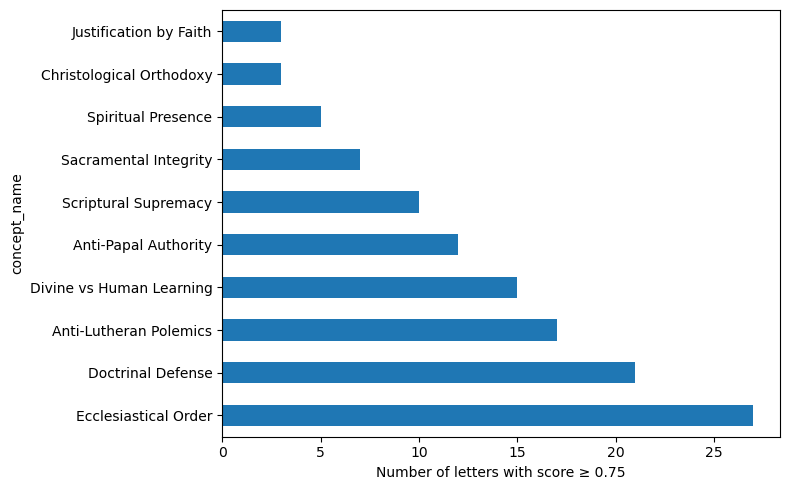

In [23]:
import matplotlib.pyplot as plt

prevalence = (
    score_df[score_df["score"] >= 0.75]
    .groupby("concept_name")["doc_id"]
    .nunique()
    .sort_values(ascending=False)
)
print(prevalence)

prevalence.plot(kind="barh", figsize=(8, 5))
plt.xlabel("Number of letters with score ≥ 0.75")
plt.tight_layout()
plt.show()

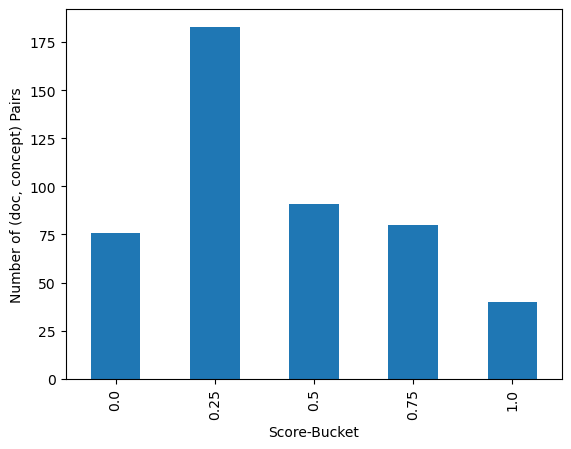

In [24]:
score_df["score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Score-Bucket")
plt.ylabel("Number of (doc, concept) Pairs")
plt.show()

In [35]:
df["year"] = df["date"].astype(str).str.extract(r"^(\d{4})").astype(float)

df["decade"] = (df["year"] // 10 * 10).astype("Int64")  # Int64 statt int, um NaN zu erlauben

print(df[["year", "decade"]].dropna().head())

     year  decade
0  1568.0    1560
1  1542.0    1540
2  1534.0    1530
3  1572.0    1570
4  1554.0    1550


In [36]:
score_with_decade = score_df.merge(df[["doc_id", "decade"]], on="doc_id", how="left")

high_score_decade = score_with_decade[score_with_decade["score"] >= 0.75]
print("high scores with decade:", high_score_decade["decade"].notna().sum(), "/", len(high_score_decade))

decade_concept = (
    high_score_decade
    .groupby(["decade", "concept_name"])["doc_id"]
    .nunique()
    .reset_index(name="n_matches")
)
print(decade_concept)

high scores with decade: 119 / 120
    decade              concept_name  n_matches
0     1530    Anti-Lutheran Polemics          3
1     1530      Anti-Papal Authority          1
2     1530  Christological Orthodoxy          1
3     1530  Divine vs Human Learning          4
4     1530         Doctrinal Defense          4
5     1530      Ecclesiastical Order          4
6     1530     Sacramental Integrity          2
7     1530      Scriptural Supremacy          3
8     1530        Spiritual Presence          1
9     1540    Anti-Lutheran Polemics          5
10    1540      Anti-Papal Authority          3
11    1540  Christological Orthodoxy          1
12    1540  Divine vs Human Learning          4
13    1540         Doctrinal Defense          4
14    1540      Ecclesiastical Order          5
15    1540    Justification by Faith          2
16    1540     Sacramental Integrity          3
17    1540      Scriptural Supremacy          2
18    1540        Spiritual Presence          2
19   

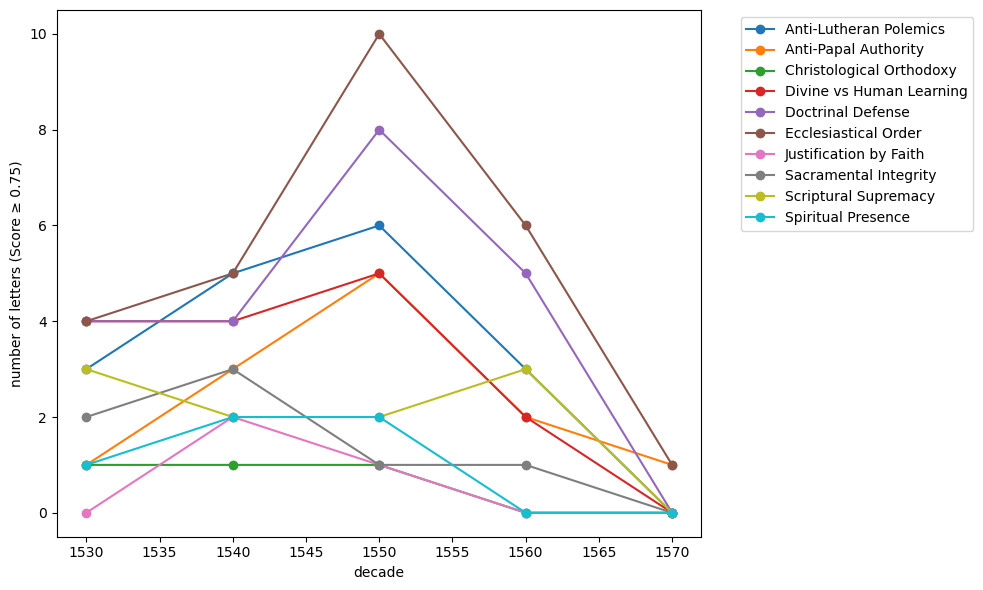

In [37]:
import matplotlib.pyplot as plt

pivot_decade = decade_concept.pivot(index="decade", columns="concept_name", values="n_matches").fillna(0)

pivot_decade.plot(kind="line", marker="o", figsize=(10, 6))
plt.xlabel("decade")
plt.ylabel("number of letters (Score ≥ 0.75)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()